In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from google.colab import files

In [ ]:
import os

os.listdir()

['.config', 'sample_data']

In [ ]:
archivo_ambiental = "Indices_Precipitacion_Feb_Oct_por_Ciudad.xlsx"
archivo_pozos = "Listado de los Pozos_RESUME.xlsx"

df_ambiental = pd.read_excel(archivo_ambiental)
df_pozos = pd.read_excel(archivo_pozos)

print("COLUMNAS AMBIENTALES:")
print(df_ambiental.columns.tolist())

print("\nCOLUMNAS POZOS:")
print(df_pozos.columns.tolist())

print("\nTAMAÑO AMBIENTAL:", df_ambiental.shape)
print("TAMAÑO POZOS:", df_pozos.shape)

COLUMNAS AMBIENTALES:
['Ovejas', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', ' Corozal', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', ' Sampués', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Morroa', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26']

COLUMNAS POZOS:
['Sampues - # 52-II-C-PZ-01', 'Unnamed: 1', 'Unnamed: 2', 'Finca el socorro (Ovejas) - # 44-II-D-PO-02', 'Unnamed: 4', 'Unnamed: 5', 'Ovejas - # 44-II-D-PO-14', 'Unnamed: 7', 'Unnamed: 8', 'Los Palmitos - # 44-IV-B-PZ-01 Piñal', 'Unnamed: 10', 'Unnamed: 11', 'Morroa (Bremen) - # 44-IV-C-PZ-01 A', 'Unnamed: 13', 'Unnamed: 14', 'Bremen - # 44-IV-C-PZ-01 B', 'Unnamed: 16', 'Unnamed: 17', 'Las Tinas (Morroa) - # 44-IV-C-PZ-02 A', 'Unnamed: 19', 'Unnamed: 20', 'Las Tinas (Morroa) - # 44-IV-C-PZ-02 B', 'Unnamed: 22', 'Unnamed: 23', 'Arroyo salida a Betulia (Corozal) - # 44-IV-D-

In [ ]:
# ============================================
# INSPECCIÓN DE DATOS DE OVEJAS
# ============================================

# Mostrar las primeras filas de las columnas de Ovejas
display(df_ambiental.iloc[:, 0:7])

,Ovejas,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Fecha,Temporada,Precipitacion_mm,NDVI,EVI,NDWI,NaN
1,2010-01-01 00:00:00,Verano (seco) - Febrero,0,0.603906,0.347119,0.114291,NaN
2,2010-10-01 00:00:00,Invierno (lluvioso) - Octubre,341,0.7408,0.6537,0.3072,NaN
3,2011-02-01 00:00:00,Verano (seco) - Febrero,17,0.6452,0.4249,0.1297,NaN
4,2011-10-01 00:00:00,Invierno (lluvioso) - Octubre,471,0.9389,0.3083,0.4598,NaN
5,2012-03-01 00:00:00,Verano (seco) - Febrero,7,0.459089,0.287387,-0.027919,NaN
6,2012-11-01 00:00:00,Invierno (lluvioso) - Octubre,123,0.814425,0.570241,0.337884,NaN
7,2013-02-01 00:00:00,Verano (seco) - Febrero,11,0.5819,0.3942,0.0747,NaN
8,2013-10-01 00:00:00,Invierno (lluvioso) - Octubre,185,0.8543,0.7413,0.3688,NaN
9,2014-02-01 00:00:00,Verano (seco) - Febrero,5,0.6077,0.3911,0.0872,NaN


In [ ]:
# ============================================
# INSPECCIÓN DEL POZO FINCA EL SOCORRO
# ============================================

display(df_pozos.iloc[:, 3:6])

,Finca el socorro (Ovejas) - # 44-II-D-PO-02,Unnamed: 4,Unnamed: 5
0,Fecha Medida,Nivel Estático (m),Imputado
1,2010-03-17 00:00:00,10.27436,0
2,2010-07-18 00:00:00,10.22,1
3,2010-12-19 00:00:00,10.23,0
4,2011-03-05 00:00:00,10.232,1
...,...,...,...
195,NaN,NaN,NaN
196,NaN,NaN,NaN
197,NaN,NaN,NaN
198,NaN,NaN,NaN


In [ ]:
# ============================================================
# 1. EXTRAER Y LIMPIAR DATOS AMBIENTALES DE OVEJAS
# ============================================================

# Las columnas 0 a 6 corresponden al bloque de Ovejas
ovejas = df_ambiental.iloc[:, 0:7].copy()

# La primera fila contiene los nombres reales de las columnas
ovejas.columns = [
    "Fecha",
    "Temporada",
    "Precipitacion_mm",
    "NDVI",
    "EVI",
    "NDWI",
    "Extra"
]

# Eliminamos la columna que está completamente vacía
ovejas = ovejas.drop(columns=["Extra"])

# Eliminamos filas completamente vacías
ovejas = ovejas.dropna(how="all")

# Convertimos Fecha a formato fecha
ovejas["Fecha"] = pd.to_datetime(ovejas["Fecha"], errors="coerce")

# Eliminamos filas donde no exista una fecha válida
ovejas = ovejas.dropna(subset=["Fecha"])

# Convertimos las variables numéricas
columnas_numericas = [
    "Precipitacion_mm",
    "NDVI",
    "EVI",
    "NDWI"
]

# Convertimos las variables a numericas

for columna in columnas_numericas:
    ovejas[columna] = pd.to_numeric(
        ovejas[columna],
        errors="coerce"
    )

# Ordenamos por fecha
ovejas = ovejas.sort_values("Fecha").reset_index(drop=True)

# Mostrar resultado
print("Datos ambientales de Ovejas:")
print(f"Número de registros: {len(ovejas)}")

display(ovejas)

Datos ambientales de Ovejas:
Número de registros: 30


/tmp/ipykernel_4007/3743127215.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ovejas["Fecha"] = pd.to_datetime(ovejas["Fecha"], errors="coerce")


,Fecha,Temporada,Precipitacion_mm,NDVI,EVI,NDWI
0,2010-01-01,Verano (seco) - Febrero,0,0.603906,0.347119,0.114291
1,2010-10-01,Invierno (lluvioso) - Octubre,341,0.740800,0.653700,0.307200
2,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700
3,2011-10-01,Invierno (lluvioso) - Octubre,471,0.938900,0.308300,0.459800
4,2012-03-01,Verano (seco) - Febrero,7,0.459089,0.287387,-0.027919
5,2012-11-01,Invierno (lluvioso) - Octubre,123,0.814425,0.570241,0.337884
6,2013-02-01,Verano (seco) - Febrero,11,0.581900,0.394200,0.074700
7,2013-10-01,Invierno (lluvioso) - Octubre,185,0.854300,0.741300,0.368800
8,2014-02-01,Verano (seco) - Febrero,5,0.607700,0.391100,0.087200
9,2014-10-01,Invierno (lluvioso) - Octubre,249,0.837300,0.677500,0.340000


In [ ]:
# ============================================================
# 2. EXTRAER Y LIMPIAR EL POZO FINCA EL SOCORRO - OVEJAS
# ============================================================

# El pozo ocupa las columnas 3, 4 y 5
pozo_socorro = df_pozos.iloc[:, 3:6].copy()

# Asignamos nombres claros
pozo_socorro.columns = [
    "Fecha",
    "Nivel_Estatico_m",
    "Imputado"
]

# Eliminamos filas completamente vacías
pozo_socorro = pozo_socorro.dropna(how="all")

# Convertimos Fecha
pozo_socorro["Fecha"] = pd.to_datetime(
    pozo_socorro["Fecha"],
    errors="coerce"
)

# Eliminamos filas sin fecha
pozo_socorro = pozo_socorro.dropna(subset=["Fecha"])

# Convertimos nivel estático a número
pozo_socorro["Nivel_Estatico_m"] = pd.to_numeric(
    pozo_socorro["Nivel_Estatico_m"],
    errors="coerce"
)

# Convertimos imputado a número entero cuando sea posible
pozo_socorro["Imputado"] = pd.to_numeric(
    pozo_socorro["Imputado"],
    errors="coerce"
)

# Ordenamos cronológicamente
pozo_socorro = pozo_socorro.sort_values(
    "Fecha"
).reset_index(drop=True)

print("Pozo Finca El Socorro - Ovejas:")
print(f"Número de mediciones: {len(pozo_socorro)}")

display(pozo_socorro)

Pozo Finca El Socorro - Ovejas:
Número de mediciones: 54


/tmp/ipykernel_4007/3945638127.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pozo_socorro["Fecha"] = pd.to_datetime(


,Fecha,Nivel_Estatico_m,Imputado
0,2010-03-17,10.274360,0
1,2010-07-18,10.220000,1
2,2010-12-19,10.230000,0
3,2011-03-05,10.232000,1
4,2011-08-11,10.200000,0
5,2012-03-17,10.190000,0
6,2012-07-23,10.110000,0
7,2012-11-12,10.130000,1
8,2013-05-07,10.160000,0
9,2013-08-20,10.340000,0


In [ ]:
print("Rango de fechas ambientales:")
print(ovejas["Fecha"].min(), "→", ovejas["Fecha"].max())

print("\nRango de fechas del pozo:")
print(pozo_socorro["Fecha"].min(), "→", pozo_socorro["Fecha"].max())

Rango de fechas ambientales:
2010-01-01 00:00:00 → 2024-10-01 00:00:00

Rango de fechas del pozo:
2010-03-17 00:00:00 → 2025-10-11 00:00:00


In [ ]:
# ============================================================
# 4. CRUCE TEMPORAL DE DATOS
# ============================================================

# Copia de los datos ambientales
ambiental = ovejas.copy()

# Guardamos la fecha ambiental original
ambiental = ambiental.rename(
    columns={"Fecha": "Fecha_Ambiental"}
)

# Copia del pozo
pozo = pozo_socorro.copy()

# Eliminamos mediciones posteriores al último dato ambiental
pozo = pozo[
    pozo["Fecha"] <= ambiental["Fecha_Ambiental"].max()
].copy()

# Ordenar por fecha
ambiental = ambiental.sort_values(
    "Fecha_Ambiental"
).reset_index(drop=True)

pozo = pozo.sort_values(
    "Fecha"
).reset_index(drop=True)

# Cruce con el dato ambiental anterior más cercano
datos = pd.merge_asof(
    pozo,
    ambiental,
    left_on="Fecha",
    right_on="Fecha_Ambiental",
    direction="backward"
)

# Diferencia entre la medición del pozo y el dato ambiental
datos["Dias_diferencia"] = (
    datos["Fecha"] - datos["Fecha_Ambiental"]
).dt.days

print("==========================================")
print("DATASET COMBINADO - OVEJAS")
print("==========================================")

print(f"Mediciones originales del pozo: {len(pozo_socorro)}")
print(f"Mediciones utilizadas: {len(pozo)}")
print(f"Registros combinados: {len(datos)}")

display(datos)

DATASET COMBINADO - OVEJAS
Mediciones originales del pozo: 54
Mediciones utilizadas: 51
Registros combinados: 51


,Fecha,Nivel_Estatico_m,Imputado,Fecha_Ambiental,Temporada,Precipitacion_mm,NDVI,EVI,NDWI,Dias_diferencia
0,2010-03-17,10.274360,0,2010-01-01,Verano (seco) - Febrero,0,0.603906,0.347119,0.114291,75
1,2010-07-18,10.220000,1,2010-01-01,Verano (seco) - Febrero,0,0.603906,0.347119,0.114291,198
2,2010-12-19,10.230000,0,2010-10-01,Invierno (lluvioso) - Octubre,341,0.740800,0.653700,0.307200,79
3,2011-03-05,10.232000,1,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700,32
4,2011-08-11,10.200000,0,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700,191
5,2012-03-17,10.190000,0,2012-03-01,Verano (seco) - Febrero,7,0.459089,0.287387,-0.027919,16
6,2012-07-23,10.110000,0,2012-03-01,Verano (seco) - Febrero,7,0.459089,0.287387,-0.027919,144
7,2012-11-12,10.130000,1,2012-11-01,Invierno (lluvioso) - Octubre,123,0.814425,0.570241,0.337884,11
8,2013-05-07,10.160000,0,2013-02-01,Verano (seco) - Febrero,11,0.581900,0.394200,0.074700,95
9,2013-08-20,10.340000,0,2013-02-01,Verano (seco) - Febrero,11,0.581900,0.394200,0.074700,200


In [ ]:
display(datos.head(15))

,Fecha,Nivel_Estatico_m,Imputado,Fecha_Ambiental,Temporada,Precipitacion_mm,NDVI,EVI,NDWI,Dias_diferencia
0,2010-03-17,10.27436,0,2010-01-01,Verano (seco) - Febrero,0,0.603906,0.347119,0.114291,75
1,2010-07-18,10.22000,1,2010-01-01,Verano (seco) - Febrero,0,0.603906,0.347119,0.114291,198
2,2010-12-19,10.23000,0,2010-10-01,Invierno (lluvioso) - Octubre,341,0.740800,0.653700,0.307200,79
3,2011-03-05,10.23200,1,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700,32
4,2011-08-11,10.20000,0,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700,191
5,2012-03-17,10.19000,0,2012-03-01,Verano (seco) - Febrero,7,0.459089,0.287387,-0.027919,16
6,2012-07-23,10.11000,0,2012-03-01,Verano (seco) - Febrero,7,0.459089,0.287387,-0.027919,144
7,2012-11-12,10.13000,1,2012-11-01,Invierno (lluvioso) - Octubre,123,0.814425,0.570241,0.337884,11
8,2013-05-07,10.16000,0,2013-02-01,Verano (seco) - Febrero,11,0.581900,0.394200,0.074700,95
9,2013-08-20,10.34000,0,2013-02-01,Verano (seco) - Febrero,11,0.581900,0.394200,0.074700,200


In [ ]:
print(datos.columns.tolist())

['Fecha', 'Nivel_Estatico_m', 'Imputado', 'Fecha_Ambiental', 'Temporada', 'Precipitacion_mm', 'NDVI', 'EVI', 'NDWI', 'Dias_diferencia']


In [ ]:
# ============================================================
# COMPARAR DATOS AMBIENTALES: ANTERIOR VS MÁS CERCANO
# ============================================================

# Copias
pozo_temp = pozo.copy()
ambiental_temp = ambiental.copy()

# ------------------------------------------------------------
# Buscar dato ambiental anterior
# ------------------------------------------------------------

anterior = pd.merge_asof(
    pozo_temp[["Fecha"]],
    ambiental_temp,
    left_on="Fecha",
    right_on="Fecha_Ambiental",
    direction="backward"
)

anterior["Dias_Anterior"] = (
    anterior["Fecha"] - anterior["Fecha_Ambiental"]
).dt.days

# ------------------------------------------------------------
# Buscar dato ambiental siguiente
# ------------------------------------------------------------

siguiente = pd.merge_asof(
    pozo_temp[["Fecha"]],
    ambiental_temp,
    left_on="Fecha",
    right_on="Fecha_Ambiental",
    direction="forward"
)

siguiente["Dias_Siguiente"] = (
    siguiente["Fecha_Ambiental"] - siguiente["Fecha"]
).dt.days

# ------------------------------------------------------------
# Elegir el registro más cercano
# ------------------------------------------------------------

resultado_cercano = pozo_temp[[
    "Fecha",
    "Nivel_Estatico_m",
    "Imputado"
]].copy()

# Fecha anterior y distancia
resultado_cercano["Fecha_Anterior"] = anterior["Fecha_Ambiental"]
resultado_cercano["Dias_Anterior"] = anterior["Dias_Anterior"]

# Fecha siguiente y distancia
resultado_cercano["Fecha_Siguiente"] = siguiente["Fecha_Ambiental"]
resultado_cercano["Dias_Siguiente"] = siguiente["Dias_Siguiente"]

# Elegimos la fecha más cercana
resultado_cercano["Fecha_Ambiental_Cercana"] = np.where(
    resultado_cercano["Dias_Anterior"].fillna(np.inf)
    <=
    resultado_cercano["Dias_Siguiente"].fillna(np.inf),
    resultado_cercano["Fecha_Anterior"],
    resultado_cercano["Fecha_Siguiente"]
)

# Convertimos nuevamente a fecha
resultado_cercano["Fecha_Ambiental_Cercana"] = pd.to_datetime(
    resultado_cercano["Fecha_Ambiental_Cercana"]
)

# Diferencia absoluta
resultado_cercano["Dias_Diferencia"] = np.minimum(
    resultado_cercano["Dias_Anterior"].fillna(np.inf),
    resultado_cercano["Dias_Siguiente"].fillna(np.inf)
)

display(resultado_cercano.head(20))

,Fecha,Nivel_Estatico_m,Imputado,Fecha_Anterior,Dias_Anterior,Fecha_Siguiente,Dias_Siguiente,Fecha_Ambiental_Cercana,Dias_Diferencia
0,2010-03-17,10.27436,0,2010-01-01,75,2010-10-01,198,2010-01-01,75
1,2010-07-18,10.22000,1,2010-01-01,198,2010-10-01,75,2010-10-01,75
2,2010-12-19,10.23000,0,2010-10-01,79,2011-02-01,44,2011-02-01,44
3,2011-03-05,10.23200,1,2011-02-01,32,2011-10-01,210,2011-02-01,32
4,2011-08-11,10.20000,0,2011-02-01,191,2011-10-01,51,2011-10-01,51
5,2012-03-17,10.19000,0,2012-03-01,16,2012-11-01,229,2012-03-01,16
6,2012-07-23,10.11000,0,2012-03-01,144,2012-11-01,101,2012-11-01,101
7,2012-11-12,10.13000,1,2012-11-01,11,2013-02-01,81,2012-11-01,11
8,2013-05-07,10.16000,0,2013-02-01,95,2013-10-01,147,2013-02-01,95
9,2013-08-20,10.34000,0,2013-02-01,200,2013-10-01,42,2013-10-01,42


In [ ]:
# ============================================================
# 5. CONSTRUIR DATASET BASE
# ============================================================

# Copia del resultado temporal
datos_base = resultado_cercano.copy()

# Unimos las variables ambientales utilizando
# la fecha ambiental más cercana
datos_base = datos_base.merge(
    ambiental,
    left_on="Fecha_Ambiental_Cercana",
    right_on="Fecha_Ambiental",
    how="left"
)

# Seleccionamos únicamente las columnas que necesitamos
datos_base = datos_base[
    [
        "Fecha",
        "Nivel_Estatico_m",
        "Imputado",
        "Fecha_Ambiental",
        "Temporada",
        "Precipitacion_mm",
        "NDVI",
        "EVI",
        "NDWI",
        "Dias_Diferencia"
    ]
]

# Ordenar por fecha
datos_base = datos_base.sort_values(
    "Fecha"
).reset_index(drop=True)

print("==========================================")
print("DATASET BASE - OVEJAS")
print("==========================================")

print(f"Registros: {len(datos_base)}")

display(datos_base)

DATASET BASE - OVEJAS
Registros: 51


,Fecha,Nivel_Estatico_m,Imputado,Fecha_Ambiental,Temporada,Precipitacion_mm,NDVI,EVI,NDWI,Dias_Diferencia
0,2010-03-17,10.274360,0,2010-01-01,Verano (seco) - Febrero,0,0.603906,0.347119,0.114291,75
1,2010-07-18,10.220000,1,2010-10-01,Invierno (lluvioso) - Octubre,341,0.740800,0.653700,0.307200,75
2,2010-12-19,10.230000,0,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700,44
3,2011-03-05,10.232000,1,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700,32
4,2011-08-11,10.200000,0,2011-10-01,Invierno (lluvioso) - Octubre,471,0.938900,0.308300,0.459800,51
5,2012-03-17,10.190000,0,2012-03-01,Verano (seco) - Febrero,7,0.459089,0.287387,-0.027919,16
6,2012-07-23,10.110000,0,2012-11-01,Invierno (lluvioso) - Octubre,123,0.814425,0.570241,0.337884,101
7,2012-11-12,10.130000,1,2012-11-01,Invierno (lluvioso) - Octubre,123,0.814425,0.570241,0.337884,11
8,2013-05-07,10.160000,0,2013-02-01,Verano (seco) - Febrero,11,0.581900,0.394200,0.074700,95
9,2013-08-20,10.340000,0,2013-10-01,Invierno (lluvioso) - Octubre,185,0.854300,0.741300,0.368800,42


In [ ]:
# ============================================================
# 6. VALORES FALTANTES
# ============================================================

print("Valores faltantes por columna:")
display(datos_base.isna().sum())

Valores faltantes por columna:


,0
Fecha,0
Nivel_Estatico_m,0
Imputado,0
Fecha_Ambiental,0
Temporada,0
Precipitacion_mm,0
NDVI,0
EVI,0
NDWI,0
Dias_Diferencia,0


In [ ]:
# ============================================================
# 7. ESTADÍSTICA BÁSICA
# ============================================================

display(
    datos_base[
        [
            "Nivel_Estatico_m",
            "Precipitacion_mm",
            "NDVI",
            "EVI",
            "NDWI"
        ]
    ].describe()
)

,Nivel_Estatico_m,Precipitacion_mm,NDVI,EVI,NDWI
count,51.000000,51.000000,51.000000,51.000000,51.000000
mean,10.160193,109.058824,0.708050,0.511104,0.203889
std,0.537372,131.500937,0.128013,0.160782,0.144610
min,9.420000,0.000000,0.459089,0.287387,-0.065300
25%,9.780833,7.500000,0.607700,0.391100,0.079300
50%,9.980000,20.000000,0.666100,0.441100,0.174200
75%,10.385000,205.000000,0.837300,0.677500,0.340000
max,11.660000,471.000000,0.938900,0.758600,0.459800


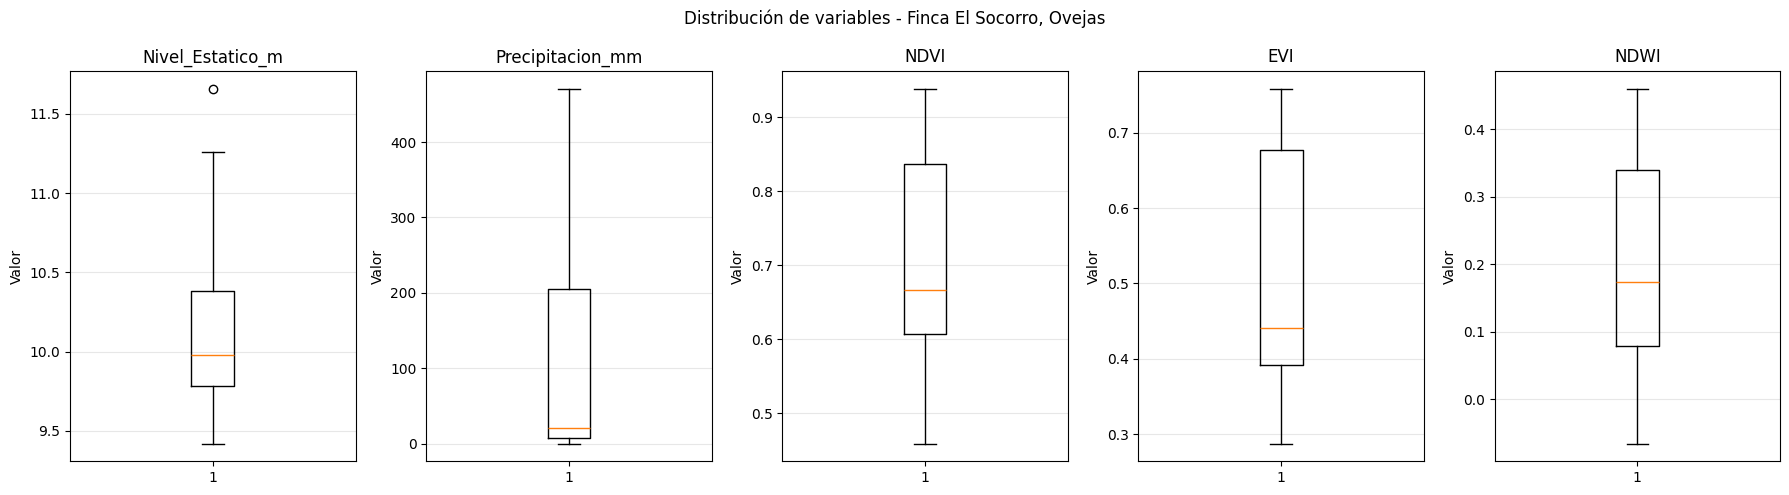

In [ ]:
# ============================================================
# 8. BOXPLOTS - OVEJAS
# ============================================================

# Seleccionamos las variables que vamos a analizar
variables = [
    "Nivel_Estatico_m",
    "Precipitacion_mm",
    "NDVI",
    "EVI",
    "NDWI"
]

# Creamos una figura con un boxplot por variable
fig, axes = plt.subplots(
    1,
    len(variables),
    figsize=(18, 5)
)

for i, variable in enumerate(variables):

    axes[i].boxplot(
        datos_base[variable].dropna()
    )

    axes[i].set_title(variable)
    axes[i].set_ylabel("Valor")
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle(
    "Distribución de variables - Finca El Socorro, Ovejas"
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

variables = [
    "Nivel_Estatico_m",
    "Precipitacion_mm",
    "NDVI",
    "EVI",
    "NDWI"
]

# Matriz de correlación de Pearson
correlacion_pearson = datos_base[variables].corr(method="pearson")

# Matriz de correlación de Spearman
correlacion_spearman = datos_base[variables].corr(method="spearman")

print("CORRELACIÓN DE PEARSON")
display(correlacion_pearson.round(3))

print("CORRELACIÓN DE SPEARMAN")
display(correlacion_spearman.round(3))

CORRELACIÓN DE PEARSON


,Nivel_Estatico_m,Precipitacion_mm,NDVI,EVI,NDWI
Nivel_Estatico_m,1.000,-0.128,-0.276,-0.110,-0.191
Precipitacion_mm,-0.128,1.000,0.800,0.715,0.839
NDVI,-0.276,0.800,1.000,0.835,0.972
EVI,-0.110,0.715,0.835,1.000,0.861
NDWI,-0.191,0.839,0.972,0.861,1.000


CORRELACIÓN DE SPEARMAN


,Nivel_Estatico_m,Precipitacion_mm,NDVI,EVI,NDWI
Nivel_Estatico_m,1.000,-0.077,-0.263,-0.200,-0.208
Precipitacion_mm,-0.077,1.000,0.773,0.719,0.792
NDVI,-0.263,0.773,1.000,0.831,0.956
EVI,-0.200,0.719,0.831,1.000,0.851
NDWI,-0.208,0.792,0.956,0.851,1.000


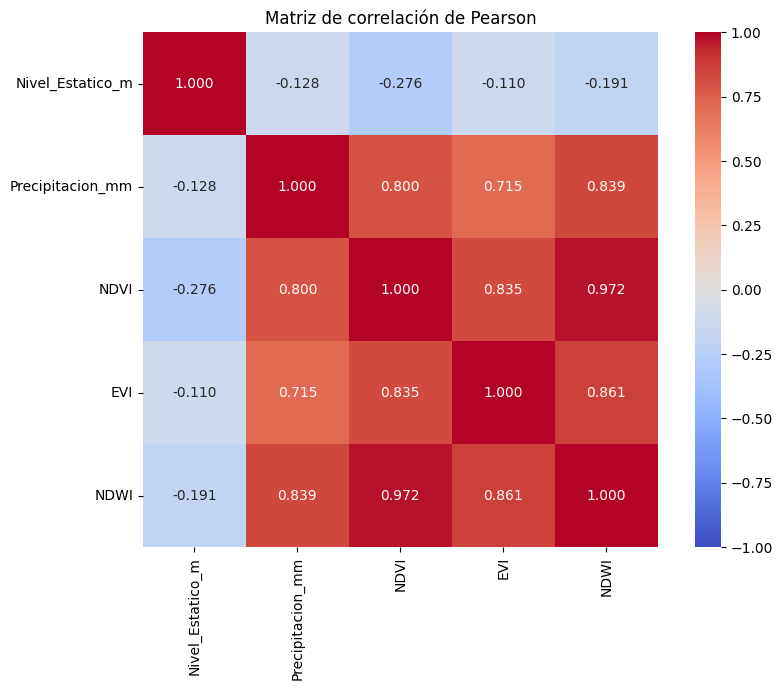

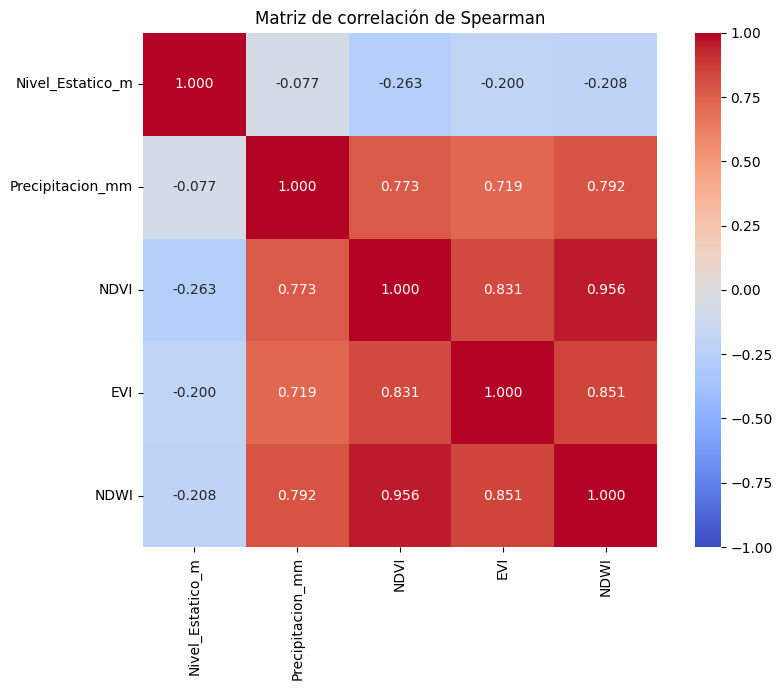

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    "Nivel_Estatico_m",
    "Precipitacion_mm",
    "NDVI",
    "EVI",
    "NDWI"
]

# -----------------------------
# MATRIZ DE PEARSON
# -----------------------------

matriz_pearson = datos_base[variables].corr(method="pearson")

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_pearson,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()


# -----------------------------
# MATRIZ DE SPEARMAN
# -----------------------------

matriz_spearman = datos_base[variables].corr(method="spearman")

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_spearman,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr, spearmanr

variables_ambientales = [
    "Precipitacion_mm",
    "NDVI",
    "EVI",
    "NDWI"
]

resultados_correlacion = []

for variable in variables_ambientales:

    datos = datos_base[
        ["Nivel_Estatico_m", variable]
    ].dropna()

    # Pearson
    r_pearson, p_pearson = pearsonr(
        datos["Nivel_Estatico_m"],
        datos[variable]
    )

    # Spearman
    r_spearman, p_spearman = spearmanr(
        datos["Nivel_Estatico_m"],
        datos[variable]
    )

    resultados_correlacion.append({
        "Variable": variable,
        "Pearson_r": r_pearson,
        "Pearson_p": p_pearson,
        "Spearman_rho": r_spearman,
        "Spearman_p": p_spearman,
        "n": len(datos)
    })

resultados_correlacion = pd.DataFrame(resultados_correlacion)

display(resultados_correlacion.round(4))

,Variable,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,n
0,Precipitacion_mm,-0.1278,0.3716,-0.0768,0.5924,51
1,NDVI,-0.2756,0.0503,-0.2630,0.0622,51
2,EVI,-0.1100,0.4423,-0.2003,0.1587,51
3,NDWI,-0.1905,0.1805,-0.2083,0.1424,51


In [ ]:
datos_lag = datos_base.copy()

# Ordenar cronológicamente
datos_lag = datos_lag.sort_values("Fecha").reset_index(drop=True)

variables_ambientales = [
    "Precipitacion_mm",
    "NDVI",
    "EVI",
    "NDWI"
]

# Crear retardos de 1, 2 y 3 observaciones
for variable in variables_ambientales:
    datos_lag[f"{variable}_lag1"] = datos_lag[variable].shift(1)
    datos_lag[f"{variable}_lag2"] = datos_lag[variable].shift(2)
    datos_lag[f"{variable}_lag3"] = datos_lag[variable].shift(3)

display(datos_lag.head(10))

,Fecha,Nivel_Estatico_m,Imputado,Fecha_Ambiental,Temporada,Precipitacion_mm,NDVI,EVI,NDWI,Dias_Diferencia,...,Precipitacion_mm_lag3,NDVI_lag1,NDVI_lag2,NDVI_lag3,EVI_lag1,EVI_lag2,EVI_lag3,NDWI_lag1,NDWI_lag2,NDWI_lag3
0,2010-03-17,10.27436,0,2010-01-01,Verano (seco) - Febrero,0,0.603906,0.347119,0.114291,75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-07-18,10.22000,1,2010-10-01,Invierno (lluvioso) - Octubre,341,0.740800,0.653700,0.307200,75,...,NaN,0.603906,NaN,NaN,0.347119,NaN,NaN,0.114291,NaN,NaN
2,2010-12-19,10.23000,0,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700,44,...,NaN,0.740800,0.603906,NaN,0.653700,0.347119,NaN,0.307200,0.114291,NaN
3,2011-03-05,10.23200,1,2011-02-01,Verano (seco) - Febrero,17,0.645200,0.424900,0.129700,32,...,0.0,0.645200,0.740800,0.603906,0.424900,0.653700,0.347119,0.129700,0.307200,0.114291
4,2011-08-11,10.20000,0,2011-10-01,Invierno (lluvioso) - Octubre,471,0.938900,0.308300,0.459800,51,...,341.0,0.645200,0.645200,0.740800,0.424900,0.424900,0.653700,0.129700,0.129700,0.307200
5,2012-03-17,10.19000,0,2012-03-01,Verano (seco) - Febrero,7,0.459089,0.287387,-0.027919,16,...,17.0,0.938900,0.645200,0.645200,0.308300,0.424900,0.424900,0.459800,0.129700,0.129700
6,2012-07-23,10.11000,0,2012-11-01,Invierno (lluvioso) - Octubre,123,0.814425,0.570241,0.337884,101,...,17.0,0.459089,0.938900,0.645200,0.287387,0.308300,0.424900,-0.027919,0.459800,0.129700
7,2012-11-12,10.13000,1,2012-11-01,Invierno (lluvioso) - Octubre,123,0.814425,0.570241,0.337884,11,...,471.0,0.814425,0.459089,0.938900,0.570241,0.287387,0.308300,0.337884,-0.027919,0.459800
8,2013-05-07,10.16000,0,2013-02-01,Verano (seco) - Febrero,11,0.581900,0.394200,0.074700,95,...,7.0,0.814425,0.814425,0.459089,0.570241,0.570241,0.287387,0.337884,0.337884,-0.027919
9,2013-08-20,10.34000,0,2013-10-01,Invierno (lluvioso) - Octubre,185,0.854300,0.741300,0.368800,42,...,123.0,0.581900,0.814425,0.814425,0.394200,0.570241,0.570241,0.074700,0.337884,0.337884


In [ ]:
from scipy.stats import pearsonr, spearmanr

resultados_lags = []

for variable in variables_ambientales:

    for lag in [0, 1, 2, 3]:

        if lag == 0:
            columna = variable
        else:
            columna = f"{variable}_lag{lag}"

        datos = datos_lag[
            ["Nivel_Estatico_m", columna]
        ].dropna()

        r_pearson, p_pearson = pearsonr(
            datos["Nivel_Estatico_m"],
            datos[columna]
        )

        rho_spearman, p_spearman = spearmanr(
            datos["Nivel_Estatico_m"],
            datos[columna]
        )

        resultados_lags.append({
            "Variable": variable,
            "Lag": lag,
            "Pearson_r": r_pearson,
            "Pearson_p": p_pearson,
            "Spearman_rho": rho_spearman,
            "Spearman_p": p_spearman,
            "n": len(datos)
        })

resultados_lags = pd.DataFrame(resultados_lags)

display(resultados_lags.round(4))

,Variable,Lag,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,n
0,Precipitacion_mm,0,-0.1278,0.3716,-0.0768,0.5924,51
1,Precipitacion_mm,1,-0.1410,0.3286,-0.0954,0.5099,50
2,Precipitacion_mm,2,-0.0512,0.7270,0.0681,0.6421,49
3,Precipitacion_mm,3,-0.0222,0.8810,0.1294,0.3805,48
4,NDVI,0,-0.2756,0.0503,-0.2630,0.0622,51
5,NDVI,1,-0.2373,0.0970,-0.2945,0.0379,50
6,NDVI,2,-0.0361,0.8057,-0.0581,0.6917,49
7,NDVI,3,0.0547,0.7119,0.0294,0.8428,48
8,EVI,0,-0.1100,0.4423,-0.2003,0.1587,51
9,EVI,1,-0.1200,0.4066,-0.2503,0.0796,50


In [ ]:
# ============================================================
# 9. PREPARACIÓN DE DATOS PARA MACHINE LEARNING
# ============================================================

# Variables predictoras (X)
datos_ml = datos_lag.dropna().copy()

X = datos_ml[[
    "Precipitacion_mm", "Precipitacion_mm_lag1", "Precipitacion_mm_lag2", "Precipitacion_mm_lag3",
    "NDVI", "NDVI_lag1", "NDVI_lag2", "NDVI_lag3",
    "EVI", "EVI_lag1", "EVI_lag2", "EVI_lag3",
    "NDWI", "NDWI_lag1", "NDWI_lag2", "NDWI_lag3"
]].copy()

# Variable objetivo (y)
y = datos_ml["Nivel_Estatico_m"].copy()

# ------------------------------------------------------------
# Verificación del dataset
# ------------------------------------------------------------

print("PREPARACIÓN PARA MACHINE LEARNING")


print("\nTamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

print("\nVariables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

# Valores nulos
print("\nValores nulos en X:")
print(X.isnull().sum())

print("\nValores nulos en y:")
print(y.isnull().sum())

# Duplicados
print("\nFilas duplicadas en X:", X.duplicated().sum())

# Tipos de datos
print("\nTipos de datos:")
print(X.dtypes)

print("\nTipo de la variable objetivo:")
print(y.dtype)

# Estadísticas
print("\nEstadísticas de las variables predictoras:")
display(X.describe())

print("\nEstadísticas de la variable objetivo:")
display(y.describe())

PREPARACIÓN PARA MACHINE LEARNING

Tamaño de X: (51, 4)
Tamaño de y: (51,)

Variables predictoras:
['Precipitacion_mm', 'NDVI', 'EVI', 'NDWI']

Variable objetivo:
Nivel_Estatico_m

Valores nulos en X:
Precipitacion_mm    0
NDVI                0
EVI                 0
NDWI                0
dtype: int64

Valores nulos en y:
0

Filas duplicadas en X: 24

Tipos de datos:
Precipitacion_mm      int64
NDVI                float64
EVI                 float64
NDWI                float64
dtype: object

Tipo de la variable objetivo:
float64

Estadísticas de las variables predictoras:


,Precipitacion_mm,NDVI,EVI,NDWI
count,51.000000,51.000000,51.000000,51.000000
mean,109.058824,0.708050,0.511104,0.203889
std,131.500937,0.128013,0.160782,0.144610
min,0.000000,0.459089,0.287387,-0.065300
25%,7.500000,0.607700,0.391100,0.079300
50%,20.000000,0.666100,0.441100,0.174200
75%,205.000000,0.837300,0.677500,0.340000
max,471.000000,0.938900,0.758600,0.459800



Estadísticas de la variable objetivo:


,Nivel_Estatico_m
count,51.000000
mean,10.160193
std,0.537372
min,9.420000
25%,9.780833
50%,9.980000
75%,10.385000
max,11.660000


In [ ]:

# 10. DATASET FINAL PARA MACHINE LEARNING

dataset_ml = X.copy()

dataset_ml["Nivel_Estatico_m"] = y

print("Dataset que será utilizado en Machine Learning:")

display(dataset_ml.head(10))

Dataset que será utilizado en Machine Learning:


,Precipitacion_mm,NDVI,EVI,NDWI,Nivel_Estatico_m
0,0,0.603906,0.347119,0.114291,10.27436
1,341,0.740800,0.653700,0.307200,10.22000
2,17,0.645200,0.424900,0.129700,10.23000
3,17,0.645200,0.424900,0.129700,10.23200
4,471,0.938900,0.308300,0.459800,10.20000
5,7,0.459089,0.287387,-0.027919,10.19000
6,123,0.814425,0.570241,0.337884,10.11000
7,123,0.814425,0.570241,0.337884,10.13000
8,11,0.581900,0.394200,0.074700,10.16000
9,185,0.854300,0.741300,0.368800,10.34000


In [ ]:
# ============================================================
# 11. DIVISIÓN DE DATOS: ENTRENAMIENTO Y PRUEBA
# ============================================================

from sklearn.model_selection import train_test_split

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=False
)

# ------------------------------------------------------------
# Verificación
# ------------------------------------------------------------

print("==========================================")
print("DIVISIÓN DE DATOS")
print("==========================================")

print("Datos totales:", len(X))
print("Datos de entrenamiento:", len(X_train))
print("Datos de prueba:", len(X_test))

print("\nTamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)

print("\nTamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

DIVISIÓN DE DATOS
Datos totales: 51
Datos de entrenamiento: 40
Datos de prueba: 11

Tamaño de X_train: (40, 4)
Tamaño de X_test: (11, 4)

Tamaño de y_train: (40,)
Tamaño de y_test: (11,)


In [ ]:
# ============================================================
# 12. MODELO RANDOM FOREST REGRESSOR
# ============================================================

from sklearn.ensemble import RandomForestRegressor

# Crear el modelo
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

print("==========================================")
print("RANDOM FOREST REGRESSOR")
print("==========================================")

print("Modelo entrenado correctamente.")
print("Número de árboles:", modelo_rf.n_estimators)

RANDOM FOREST REGRESSOR
Modelo entrenado correctamente.
Número de árboles: 100


In [ ]:
# ============================================================
# 13. PREDICCIONES DEL RANDOM FOREST
# ============================================================

# Realizar predicciones sobre los datos de prueba
y_pred_rf = modelo_rf.predict(X_test)

print("==========================================")
print("PREDICCIONES - RANDOM FOREST")
print("==========================================")

# Comparar valores reales vs. predichos
comparacion_rf = pd.DataFrame({
    "Nivel_Real": y_test.values,
    "Nivel_Predicho": y_pred_rf
})

display(comparacion_rf)

PREDICCIONES - RANDOM FOREST


,Nivel_Real,Nivel_Predicho
0,9.8730,9.872185
1,9.7700,10.032684
2,9.9000,10.119129
3,9.4600,9.759948
4,11.2600,11.046350
5,9.7350,10.019833
6,10.3500,10.093651
7,9.7225,10.019833
8,10.2320,10.133349
9,9.7100,9.817189


In [ ]:
# ============================================================
# 14. EVALUACIÓN DEL RANDOM FOREST
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcular métricas
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("==========================================")
print("EVALUACIÓN - RANDOM FOREST")
print("==========================================")

print(f"MAE  : {mae_rf:.4f} m")
print(f"RMSE : {rmse_rf:.4f} m")
print(f"R²   : {r2_rf:.4f}")

EVALUACIÓN - RANDOM FOREST
MAE  : 0.1973 m
RMSE : 0.2187 m
R²   : 0.7787


In [ ]:
# ============================================================
# 15. MODELO XGBOOST REGRESSOR
# ============================================================

from xgboost import XGBRegressor

# Crear el modelo
modelo_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    objective="reg:squarederror"
)

# Entrenar el modelo
modelo_xgb.fit(X_train, y_train)

print("==========================================")
print("XGBOOST REGRESSOR")
print("==========================================")

print("Modelo entrenado correctamente.")
print("Número de árboles:", modelo_xgb.n_estimators)

XGBOOST REGRESSOR
Modelo entrenado correctamente.
Número de árboles: 100


In [ ]:
# ============================================================
# 16. PREDICCIONES - XGBOOST
# ============================================================

# Realizar predicciones sobre los datos de prueba
y_pred_xgb = modelo_xgb.predict(X_test)

print("==========================================")
print("PREDICCIONES - XGBOOST")
print("==========================================")

# Comparar valores reales vs. predichos
comparacion_xgb = pd.DataFrame({
    "Nivel_Real": y_test.values,
    "Nivel_Predicho": y_pred_xgb
})

display(comparacion_xgb)

PREDICCIONES - XGBOOST


,Nivel_Real,Nivel_Predicho
0,9.8730,9.884143
1,9.7700,10.202853
2,9.9000,9.998086
3,9.4600,9.781644
4,11.2600,11.152252
5,9.7350,10.138491
6,10.3500,10.017516
7,9.7225,10.138491
8,10.2320,10.155371
9,9.7100,9.839425


In [ ]:
# ============================================================
# 17. EVALUACIÓN DE XGBOOST
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcular métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("==========================================")
print("EVALUACIÓN - XGBOOST")
print("==========================================")

print(f"MAE  : {mae_xgb:.4f} m")
print(f"RMSE : {rmse_xgb:.4f} m")
print(f"R²   : {r2_xgb:.4f}")

EVALUACIÓN - XGBOOST
MAE  : 0.2216 m
RMSE : 0.2685 m
R²   : 0.6664


In [ ]:
# ============================================================
# 18. IMPORTANCIA DE LAS VARIABLES - RANDOM FOREST
# ============================================================

import pandas as pd

importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

# Ordenar de mayor a menor
importancias_rf = importancias_rf.sort_values(
    by="Importancia",
    ascending=False
).reset_index(drop=True)

print("==========================================")
print("IMPORTANCIA DE VARIABLES - RANDOM FOREST")
print("==========================================")

display(importancias_rf)

IMPORTANCIA DE VARIABLES - RANDOM FOREST


,Variable,Importancia
0,NDVI,0.429603
1,EVI,0.225917
2,NDWI,0.180781
3,Precipitacion_mm,0.163698


In [ ]:
# ============================================================
# 19. IMPORTANCIA DE LAS VARIABLES - XGBOOST
# ============================================================

importancias_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_xgb.feature_importances_
})

# Ordenar de mayor a menor
importancias_xgb = importancias_xgb.sort_values(
    by="Importancia",
    ascending=False
).reset_index(drop=True)

print("==========================================")
print("IMPORTANCIA DE VARIABLES - XGBOOST")
print("==========================================")

display(importancias_xgb)

IMPORTANCIA DE VARIABLES - XGBOOST


,Variable,Importancia
0,NDWI,0.427093
1,NDVI,0.383526
2,EVI,0.147331
3,Precipitacion_mm,0.042050


In [ ]:
# ============================================================
# 20. VALIDACIÓN CRUZADA DE LOS MODELOS
# ============================================================

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np

# ------------------------------------------------------------
# Configurar validación cruzada
# ------------------------------------------------------------

cv = TimeSeriesSplit(
    n_splits=5
)

# ------------------------------------------------------------
# Crear nuevamente los modelos
# ------------------------------------------------------------

modelo_rf_cv = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_xgb_cv = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    objective="reg:squarederror"
)

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

resultados_rf_cv = cross_validate(
    modelo_rf_cv,
    X,
    y,
    cv=cv,
    scoring=scoring
)

# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

resultados_xgb_cv = cross_validate(
    modelo_xgb_cv,
    X,
    y,
    cv=cv,
    scoring=scoring
)

# ------------------------------------------------------------
# Convertir errores negativos a positivos
# ------------------------------------------------------------

mae_rf_cv = -resultados_rf_cv["test_MAE"].mean()
rmse_rf_cv = -resultados_rf_cv["test_RMSE"].mean()
r2_rf_cv = resultados_rf_cv["test_R2"].mean()

mae_xgb_cv = -resultados_xgb_cv["test_MAE"].mean()
rmse_xgb_cv = -resultados_xgb_cv["test_RMSE"].mean()
r2_xgb_cv = resultados_xgb_cv["test_R2"].mean()

# ------------------------------------------------------------
# Mostrar resultados
# ------------------------------------------------------------

print("==========================================")
print("VALIDACIÓN CRUZADA - 5 FOLDS")
print("==========================================")

print("\nRANDOM FOREST")
print(f"MAE promedio  : {mae_rf_cv:.4f} m")
print(f"RMSE promedio : {rmse_rf_cv:.4f} m")
print(f"R² promedio   : {r2_rf_cv:.4f}")

print("\nXGBOOST")
print(f"MAE promedio  : {mae_xgb_cv:.4f} m")
print(f"RMSE promedio : {rmse_xgb_cv:.4f} m")
print(f"R² promedio   : {r2_xgb_cv:.4f}")

VALIDACIÓN CRUZADA - 5 FOLDS

RANDOM FOREST
MAE promedio  : 0.2827 m
RMSE promedio : 0.3614 m
R² promedio   : 0.4825

XGBOOST
MAE promedio  : 0.2891 m
RMSE promedio : 0.3704 m
R² promedio   : 0.4696


In [ ]:
# ============================================================
# 21. RESULTADOS DE CADA FOLD
# ============================================================

print("==========================================")
print("RESULTADOS POR FOLD")
print("==========================================")

# Random Forest
rf_folds = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": -resultados_rf_cv["test_MAE"],
    "RMSE": -resultados_rf_cv["test_RMSE"],
    "R2": resultados_rf_cv["test_R2"]
})

print("\nRANDOM FOREST")
display(rf_folds)

# XGBoost
xgb_folds = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": -resultados_xgb_cv["test_MAE"],
    "RMSE": -resultados_xgb_cv["test_RMSE"],
    "R2": resultados_xgb_cv["test_R2"]
})

print("\nXGBOOST")
display(xgb_folds)

RESULTADOS POR FOLD

RANDOM FOREST


,Fold,MAE,RMSE,R2
0,1,0.209511,0.229670,0.755910
1,2,0.237248,0.320643,0.261555
2,3,0.382913,0.445326,0.525143
3,4,0.240025,0.327316,0.451709
4,5,0.343779,0.484049,0.418024



XGBOOST


,Fold,MAE,RMSE,R2
0,1,0.221623,0.268486,0.666431
1,2,0.240464,0.318400,0.271852
2,3,0.411743,0.468238,0.475023
3,4,0.211808,0.280444,0.597496
4,5,0.359803,0.516494,0.337392


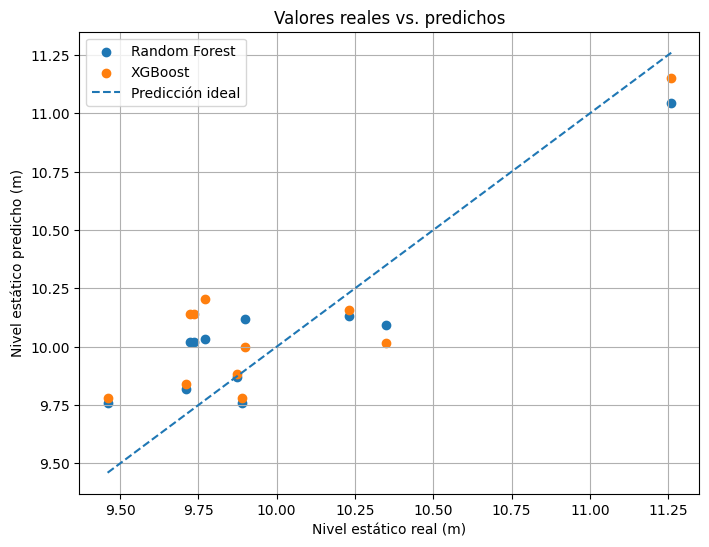

In [ ]:
# ============================================================
# 22. GRÁFICO: VALORES REALES VS. PREDICHOS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    label="Random Forest"
)

plt.scatter(
    y_test,
    y_pred_xgb,
    label="XGBoost"
)

# Línea ideal: predicción = valor real
min_val = min(y_test.min(), y_pred_rf.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_rf.max(), y_pred_xgb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Predicción ideal"
)

plt.xlabel("Nivel estático real (m)")
plt.ylabel("Nivel estático predicho (m)")
plt.title("Valores reales vs. predichos")
plt.legend()
plt.grid(True)

plt.show()

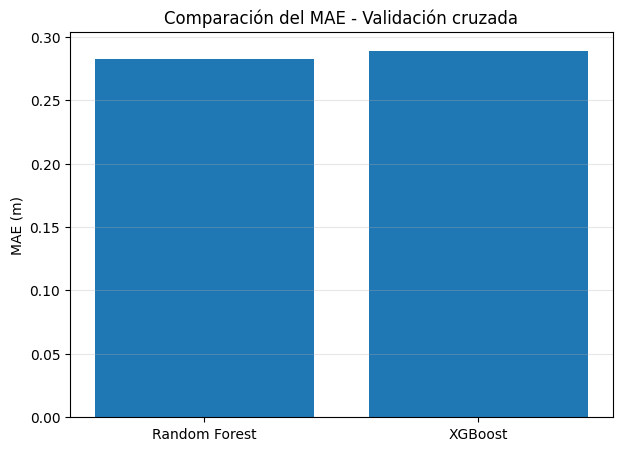

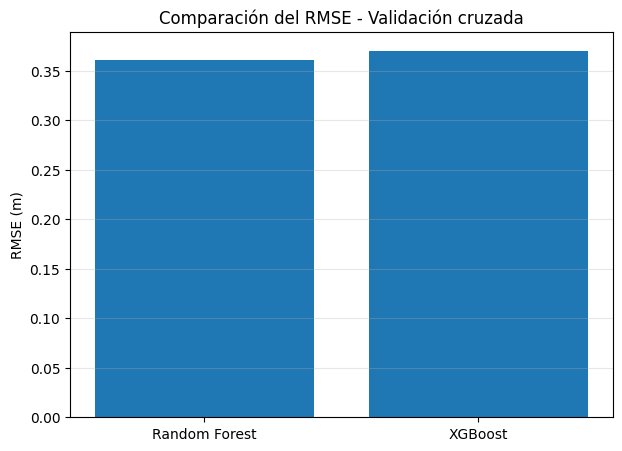

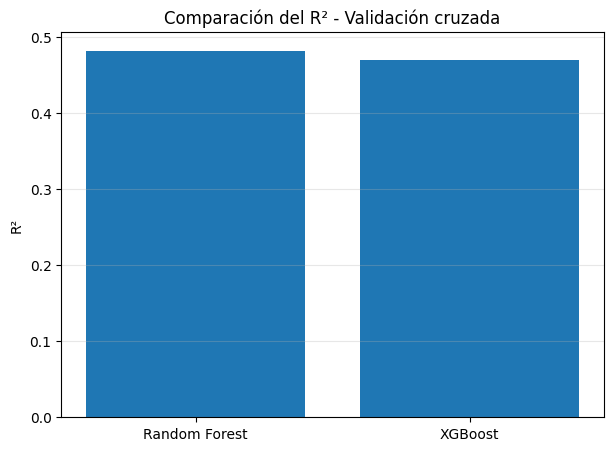

In [ ]:
# ============================================================
# 23. COMPARACIÓN DE MODELOS - VALIDACIÓN CRUZADA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

modelos = ["Random Forest", "XGBoost"]

mae = [mae_rf_cv, mae_xgb_cv]
rmse = [rmse_rf_cv, rmse_xgb_cv]
r2 = [r2_rf_cv, r2_xgb_cv]

# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(modelos, mae)

plt.ylabel("MAE (m)")
plt.title("Comparación del MAE - Validación cruzada")
plt.grid(axis="y", alpha=0.3)

plt.show()

# ------------------------------------------------------------
# RMSE
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(modelos, rmse)

plt.ylabel("RMSE (m)")
plt.title("Comparación del RMSE - Validación cruzada")
plt.grid(axis="y", alpha=0.3)

plt.show()

# ------------------------------------------------------------
# R²
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(modelos, r2)

plt.ylabel("R²")
plt.title("Comparación del R² - Validación cruzada")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:

# 24. PREDICCIONES FUERA DE MUESTRA (OUT-OF-FOLD)

from sklearn.model_selection import cross_val_predict

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

pred_rf_oof = cross_val_predict(
    modelo_rf_cv,
    X,
    y,
    cv=cv
)

# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

pred_xgb_oof = cross_val_predict(
    modelo_xgb_cv,
    X,
    y,
    cv=cv
)

print("PREDICCIONES OUT-OF-FOLD")


print("Número de predicciones Random Forest:", len(pred_rf_oof))
print("Número de predicciones XGBoost:", len(pred_xgb_oof))

display(pd.DataFrame({
    "Nivel_Real": y.values,
    "RF_OOF": pred_rf_oof,
    "XGB_OOF": pred_xgb_oof
}).head(10))

PREDICCIONES OUT-OF-FOLD
Número de predicciones Random Forest: 51
Número de predicciones XGBoost: 51


,Nivel_Real,RF_OOF,XGB_OOF
0,10.27436,9.915074,10.562005
1,10.22000,10.433378,10.472378
2,10.23000,10.040425,10.000447
3,10.23200,10.131454,10.155371
4,10.20000,10.249265,9.928894
5,10.19000,10.994649,10.749967
6,10.11000,10.043664,10.106608
7,10.13000,10.214156,10.082984
8,10.16000,10.073691,10.310312
9,10.34000,9.571577,9.569892


In [ ]:
# ============================================================
# 25. CORRELACIÓN DE LAS VARIABLES CON LOS MODELOS ML
# ============================================================

from scipy.stats import pearsonr, spearmanr

variables = [
    "Precipitacion_mm",
    "NDVI",
    "EVI",
    "NDWI"
]

resultados_correlacion_ml = []

for variable in variables:

    # --------------------------------------------------------
    # Correlación con Random Forest
    # --------------------------------------------------------

    r_rf, p_rf = pearsonr(
        X[variable],
        pred_rf_oof
    )

    rho_rf, p_s_rf = spearmanr(
        X[variable],
        pred_rf_oof
    )

    # --------------------------------------------------------
    # Correlación con XGBoost
    # --------------------------------------------------------

    r_xgb, p_xgb = pearsonr(
        X[variable],
        pred_xgb_oof
    )

    rho_xgb, p_s_xgb = spearmanr(
        X[variable],
        pred_xgb_oof
    )

    resultados_correlacion_ml.append({
        "Variable": variable,

        "RF_Pearson_r": r_rf,
        "RF_Pearson_p": p_rf,

        "RF_Spearman_rho": rho_rf,
        "RF_Spearman_p": p_s_rf,

        "XGB_Pearson_r": r_xgb,
        "XGB_Pearson_p": p_xgb,

        "XGB_Spearman_rho": rho_xgb,
        "XGB_Spearman_p": p_s_xgb
    })

tabla_correlacion_ml = pd.DataFrame(
    resultados_correlacion_ml
)

print("==========================================")
print("CORRELACIÓN VARIABLES VS. MODELOS ML")
print("==========================================")

display(tabla_correlacion_ml)

CORRELACIÓN VARIABLES VS. MODELOS ML


,Variable,RF_Pearson_r,RF_Pearson_p,RF_Spearman_rho,RF_Spearman_p,XGB_Pearson_r,XGB_Pearson_p,XGB_Spearman_rho,XGB_Spearman_p
0,Precipitacion_mm,-0.152504,0.285357,0.073409,0.608694,-0.249442,0.077525,-0.045711,0.750092
1,NDVI,-0.334482,0.016440,-0.246709,0.080939,-0.410982,0.002737,-0.352692,0.011135
2,EVI,-0.146289,0.305675,-0.207192,0.144607,-0.181244,0.203081,-0.226797,0.109502
3,NDWI,-0.229161,0.105755,-0.196678,0.166574,-0.296037,0.034923,-0.279185,0.047256


In [ ]:
# ============================================================
# 26. TABLA CONSOLIDADA DEL ANÁLISIS
# ============================================================

# ------------------------------------------------------------
# Correlaciones con el nivel estático real
# ------------------------------------------------------------

correlacion_nivel = []

for variable in variables:

    r_nivel, p_nivel = pearsonr(
        X[variable],
        y
    )

    correlacion_nivel.append({
        "Variable": variable,
        "Nivel_Pearson_r": r_nivel,
        "Nivel_Pearson_p": p_nivel
    })

tabla_nivel = pd.DataFrame(correlacion_nivel)

# ------------------------------------------------------------
# Importancias de Random Forest
# ------------------------------------------------------------

tabla_rf_importancia = importancias_rf.rename(
    columns={"Importancia": "RF_Importancia"}
)

# ------------------------------------------------------------
# Importancias de XGBoost
# ------------------------------------------------------------

tabla_xgb_importancia = importancias_xgb.rename(
    columns={"Importancia": "XGB_Importancia"}
)

# ------------------------------------------------------------
# Seleccionar solo columnas necesarias
# ------------------------------------------------------------

tabla_rf_importancia = tabla_rf_importancia[
    ["Variable", "RF_Importancia"]
]

tabla_xgb_importancia = tabla_xgb_importancia[
    ["Variable", "XGB_Importancia"]
]

# ------------------------------------------------------------
# Correlaciones con los modelos
# ------------------------------------------------------------

tabla_corr_modelos = tabla_correlacion_ml[
    [
        "Variable",
        "RF_Pearson_r",
        "RF_Pearson_p",
        "XGB_Pearson_r",
        "XGB_Pearson_p"
    ]
]

# ------------------------------------------------------------
# Unir toda la información
# ------------------------------------------------------------

tabla_final = tabla_nivel.merge(
    tabla_corr_modelos,
    on="Variable"
)

tabla_final = tabla_final.merge(
    tabla_rf_importancia,
    on="Variable"
)

tabla_final = tabla_final.merge(
    tabla_xgb_importancia,
    on="Variable"
)

# ------------------------------------------------------------
# Ordenar las columnas
# ------------------------------------------------------------

tabla_final = tabla_final[
    [
        "Variable",

        "Nivel_Pearson_r",
        "Nivel_Pearson_p",

        "RF_Pearson_r",
        "RF_Pearson_p",
        "RF_Importancia",

        "XGB_Pearson_r",
        "XGB_Pearson_p",
        "XGB_Importancia"
    ]
]

print("==========================================")
print("TABLA CONSOLIDADA DEL ANÁLISIS")
print("==========================================")

display(tabla_final.round(4))

TABLA CONSOLIDADA DEL ANÁLISIS


,Variable,Nivel_Pearson_r,Nivel_Pearson_p,RF_Pearson_r,RF_Pearson_p,RF_Importancia,XGB_Pearson_r,XGB_Pearson_p,XGB_Importancia
0,Precipitacion_mm,-0.1278,0.3716,-0.1525,0.2854,0.1637,-0.2494,0.0775,0.0421
1,NDVI,-0.2756,0.0503,-0.3345,0.0164,0.4296,-0.4110,0.0027,0.3835
2,EVI,-0.1100,0.4423,-0.1463,0.3057,0.2259,-0.1812,0.2031,0.1473
3,NDWI,-0.1905,0.1805,-0.2292,0.1058,0.1808,-0.2960,0.0349,0.4271


MATRIZ DE CORRELACIÓN DE PEARSON


,Precipitacion_mm,NDVI,EVI,NDWI,Nivel_Estatico_m
Precipitacion_mm,1.0000,0.7998,0.7148,0.8388,-0.1278
NDVI,0.7998,1.0000,0.8351,0.9725,-0.2756
EVI,0.7148,0.8351,1.0000,0.8613,-0.1100
NDWI,0.8388,0.9725,0.8613,1.0000,-0.1905
Nivel_Estatico_m,-0.1278,-0.2756,-0.1100,-0.1905,1.0000


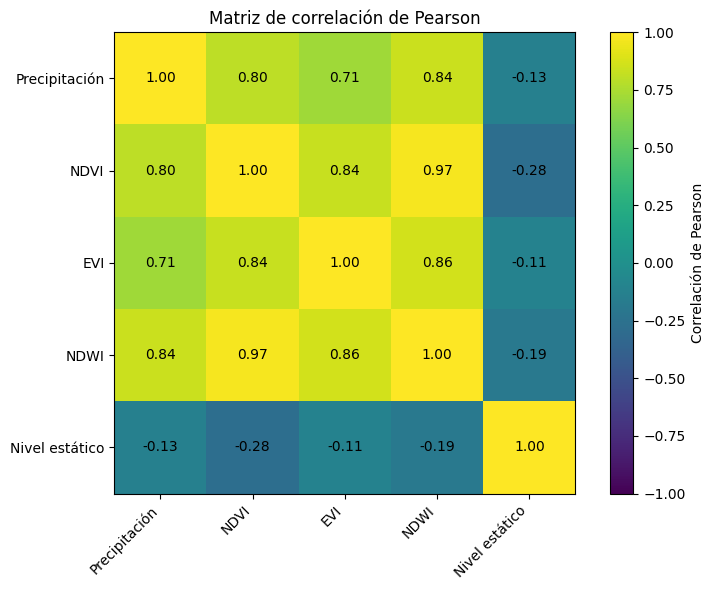

In [ ]:
# ============================================================
# 27. MAPA DE CORRELACIÓN DE PEARSON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Crear una copia de X y agregar la variable objetivo
datos_correlacion = X.copy()
datos_correlacion["Nivel_Estatico_m"] = y

# Matriz de correlación de Pearson
matriz_pearson = datos_correlacion.corr(method="pearson")

print("==========================================")
print("MATRIZ DE CORRELACIÓN DE PEARSON")
print("==========================================")

display(matriz_pearson.round(4))

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

nombres = [
    "Precipitación",
    "NDVI",
    "EVI",
    "NDWI",
    "Nivel estático"
]

fig, ax = plt.subplots(figsize=(8, 6))

imagen = ax.imshow(
    matriz_pearson,
    vmin=-1,
    vmax=1
)

# Ejes
ax.set_xticks(range(len(nombres)))
ax.set_yticks(range(len(nombres)))

ax.set_xticklabels(
    nombres,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(nombres)

# Valores dentro de las celdas
for i in range(len(nombres)):
    for j in range(len(nombres)):
        ax.text(
            j,
            i,
            f"{matriz_pearson.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(
    imagen,
    label="Correlación de Pearson"
)

plt.title(
    "Matriz de correlación de Pearson"
)

plt.tight_layout()
plt.show()

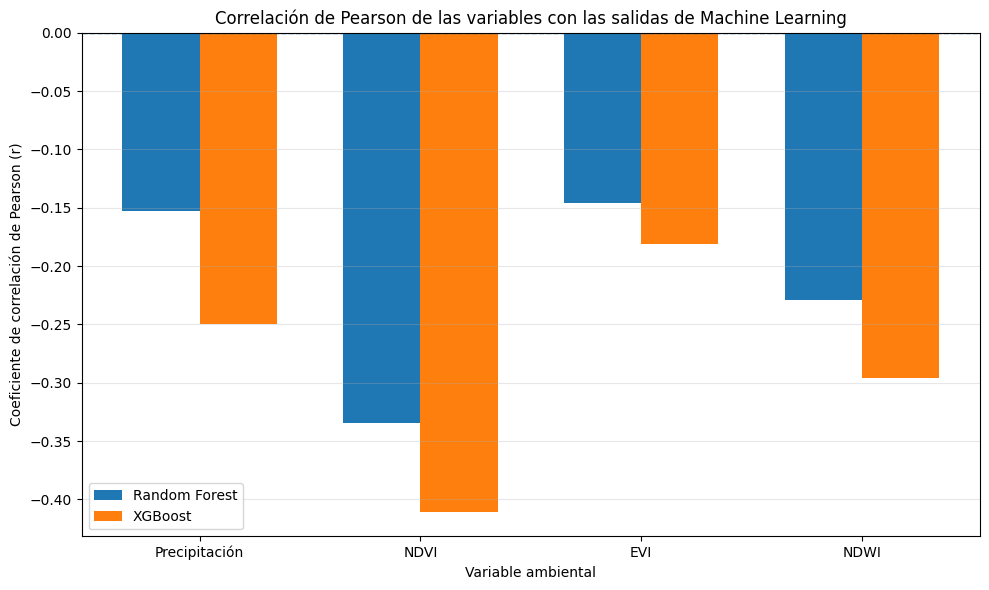

In [ ]:
# ============================================================
# 28. CORRELACIÓN DE PEARSON CON LOS MODELOS ML
# ============================================================

# Obtener los coeficientes de correlación
rf_pearson = tabla_correlacion_ml["RF_Pearson_r"]
xgb_pearson = tabla_correlacion_ml["XGB_Pearson_r"]

# Variables
variables_grafico = [
    "Precipitación",
    "NDVI",
    "EVI",
    "NDWI"
]

# Posiciones en el eje X
x = np.arange(len(variables_grafico))

# Ancho de las barras
ancho = 0.35

# Crear gráfico
plt.figure(figsize=(10, 6))

plt.bar(
    x - ancho / 2,
    rf_pearson,
    ancho,
    label="Random Forest"
)

plt.bar(
    x + ancho / 2,
    xgb_pearson,
    ancho,
    label="XGBoost"
)

# Línea de referencia en cero
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

# Configuración de ejes
plt.xticks(
    x,
    variables_grafico
)

plt.ylabel(
    "Coeficiente de correlación de Pearson (r)"
)

plt.xlabel(
    "Variable ambiental"
)

plt.title(
    "Correlación de Pearson de las variables con las salidas de Machine Learning"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

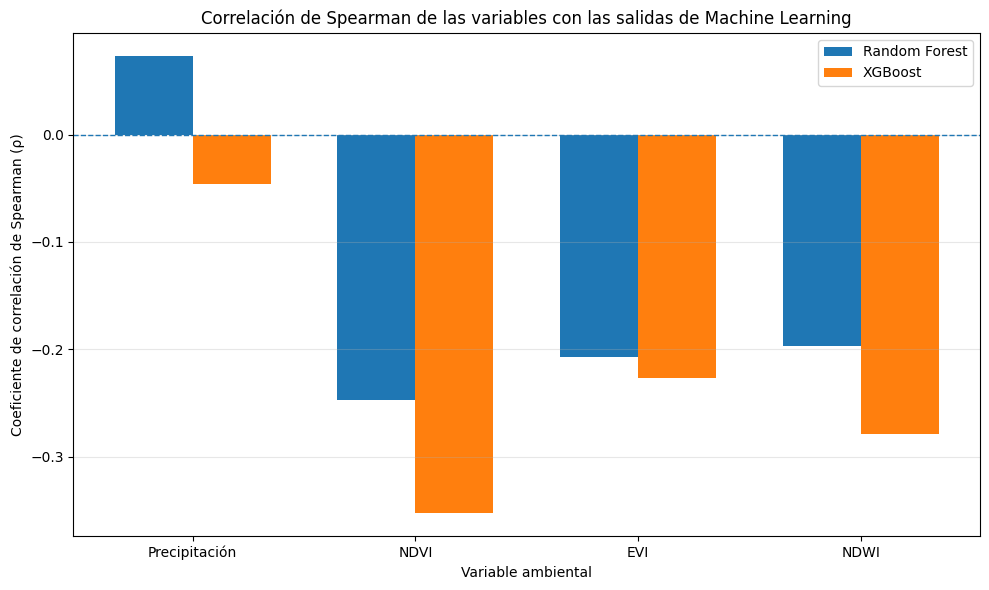

In [ ]:
# ============================================================
# 29. CORRELACIÓN DE SPEARMAN CON LOS MODELOS ML
# ============================================================

# Obtener los coeficientes de correlación
rf_spearman = tabla_correlacion_ml["RF_Spearman_rho"]
xgb_spearman = tabla_correlacion_ml["XGB_Spearman_rho"]

# Variables
variables_grafico = [
    "Precipitación",
    "NDVI",
    "EVI",
    "NDWI"
]

# Posiciones en el eje X
x = np.arange(len(variables_grafico))

# Ancho de las barras
ancho = 0.35

# Crear gráfico
plt.figure(figsize=(10, 6))

plt.bar(
    x - ancho / 2,
    rf_spearman,
    ancho,
    label="Random Forest"
)

plt.bar(
    x + ancho / 2,
    xgb_spearman,
    ancho,
    label="XGBoost"
)

# Línea de referencia en cero
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

# Configuración de ejes
plt.xticks(
    x,
    variables_grafico
)

plt.ylabel(
    "Coeficiente de correlación de Spearman (ρ)"
)

plt.xlabel(
    "Variable ambiental"
)

plt.title(
    "Correlación de Spearman de las variables con las salidas de Machine Learning"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

MATRIZ DE CORRELACIÓN DE SPEARMAN


,Precipitacion_mm,NDVI,EVI,NDWI,Nivel_Estatico_m
Precipitacion_mm,1.0000,0.7729,0.7189,0.7922,-0.0768
NDVI,0.7729,1.0000,0.8312,0.9560,-0.2630
EVI,0.7189,0.8312,1.0000,0.8507,-0.2003
NDWI,0.7922,0.9560,0.8507,1.0000,-0.2083
Nivel_Estatico_m,-0.0768,-0.2630,-0.2003,-0.2083,1.0000


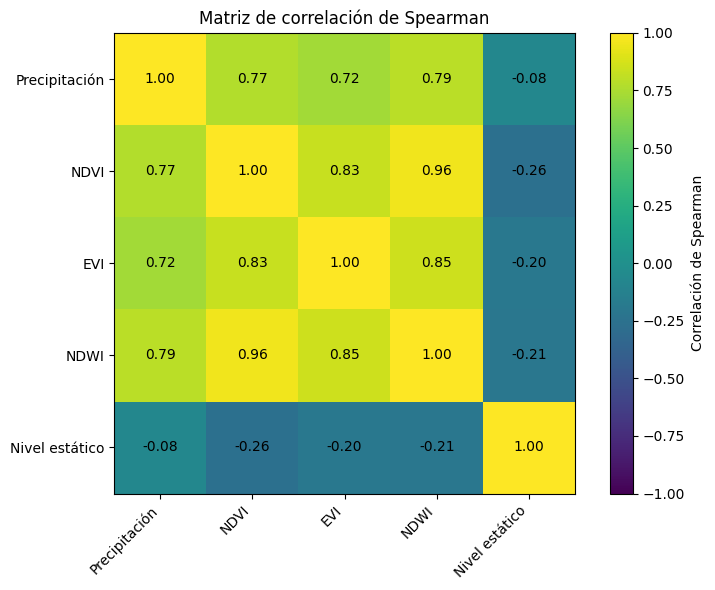

In [ ]:
# ============================================================
# 30. MAPA DE CORRELACIÓN DE SPEARMAN
# ============================================================

# Crear una copia de X y agregar la variable objetivo
datos_correlacion = X.copy()
datos_correlacion["Nivel_Estatico_m"] = y

# Matriz de correlación de Spearman
matriz_spearman = datos_correlacion.corr(method="spearman")

print("==========================================")
print("MATRIZ DE CORRELACIÓN DE SPEARMAN")
print("==========================================")

display(matriz_spearman.round(4))

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

nombres = [
    "Precipitación",
    "NDVI",
    "EVI",
    "NDWI",
    "Nivel estático"
]

fig, ax = plt.subplots(figsize=(8, 6))

imagen = ax.imshow(
    matriz_spearman,
    vmin=-1,
    vmax=1
)

# Configurar ejes
ax.set_xticks(range(len(nombres)))
ax.set_yticks(range(len(nombres)))

ax.set_xticklabels(
    nombres,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(nombres)

# Mostrar valores en cada celda
for i in range(len(nombres)):
    for j in range(len(nombres)):
        ax.text(
            j,
            i,
            f"{matriz_spearman.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(
    imagen,
    label="Correlación de Spearman"
)

plt.title(
    "Matriz de correlación de Spearman"
)

plt.tight_layout()
plt.show()